# 🌿 EcoVista AI — Full Model Training Pipeline
### Kaggle Notebook | GPU Accelerated

This notebook generates **synthetic IIT-Delhi-scale campus data** and trains **7 AI models** used across the EcoVista platform:

| # | Model | Output Table | Output Columns |
|---|-------|-------------|---------------|
| 1 | LSTM Energy Forecaster | `energy_forecasts` | `predicted_kw`, `upper_bound_kw`, `lower_bound_kw` |
| 2 | Carbon Regression | `carbon_monthly_trend` | `forecast_tco2e` |
| 3 | K-Means Building Clustering | `buildings` | `hvac_score`, `carbon_score`, `efficiency_cluster` |
| 4 | Isolation Forest Anomaly Detection | `alerts` | auto-generate `alert_type: critical` |
| 5 | Retrofit ROI Scorer | `retrofit_suggestions` | `payback_years`, `annual_saving`, `carbon_reduction_tons` |
| 6 | Recommendation Engine | `ai_recommendations` | `roi_pct`, `ease_score`, `confidence_pct`, `priority` |
| 7 | Load Profile Classifier | `load_profiles` | weekday/weekend/holiday patterns |

**All model files are saved as `.pkl` (scikit-learn) or `.keras` (LSTM). After downloading, you upload them to Supabase Storage and call them from Edge Functions.**

---
## 0. Install & Import

In [4]:
!pip install -q scikit-learn tensorflow joblib pandas numpy matplotlib seaborn

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import IsolationForest, GradientBoostingRegressor, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Check GPU
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
np.random.seed(42)
tf.random.set_seed(42)

# Output directory
os.makedirs('/kaggle/working/models', exist_ok=True)
MODELS_DIR = '/kaggle/working/models'

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 1. Synthetic Data Generation
Simulates 2 years of hourly data for an IIT-Delhi-scale campus:
- Peak demand: 4–6 MW
- Solar capacity: 2 MWp
- 20 buildings of varying type
- Indian climate: hot summers, mild winters, monsoon effect

In [6]:
# ─── 1A. Time index ───────────────────────────────────────────────────────────
START = datetime(2023, 1, 1)
HOURS = 365 * 2 * 24   # 2 years hourly
idx = pd.date_range(START, periods=HOURS, freq='h')

# Extract as NumPy arrays immediately to avoid pandas Index immutability issues
hour   = idx.hour.to_numpy()
dow    = idx.dayofweek.to_numpy()       # 0=Mon … 6=Sun
month  = idx.month.to_numpy()
doy    = idx.dayofyear.to_numpy()

# ─── 1B. Temperature (°C) — Indian climate ────────────────────────────────────
# Annual cycle: min ~10°C (Dec/Jan), max ~42°C (May/Jun)
temp_base   = 26 + 16 * np.sin(2 * np.pi * (doy - 105) / 365)   # seasonal
temp_daily  = -5 * np.cos(2 * np.pi * hour / 24)                 # diurnal swing
temp_noise  = np.random.normal(0, 1.5, HOURS)
temperature = temp_base + temp_daily + temp_noise

# ─── 1C. Occupancy ratio (0–1) ────────────────────────────────────────────────
# Weekday: bell-curve 8 AM–8 PM, Weekend/holiday: ~20%
occupancy_base = np.where(
    dow < 5,
    np.clip(np.exp(-0.5 * ((hour - 13) / 4) ** 2), 0.05, 1.0),
    0.20
)
# Semester break months (May, Dec): lower occupancy
semester_factor = np.where(np.isin(month, [5, 12]), 0.4, 1.0)
occupancy = np.clip(occupancy_base * semester_factor + np.random.normal(0, 0.03, HOURS), 0.05, 1.0)

# ─── 1D. Solar irradiance (normalised 0–1) ────────────────────────────────────
# Peak solar noon, zero at night, reduced in monsoon (Jul–Sep)
solar_curve = np.where(
    (hour >= 6) & (hour <= 18),
    np.clip(np.sin(np.pi * (hour - 6) / 12), 0, 1),
    0
)
monsoon_factor = np.where(np.isin(month, [7, 8, 9]), 0.45, 1.0)
cloud_noise    = np.clip(np.random.beta(5, 2, HOURS), 0.1, 1.0)
solar_irr      = solar_curve * monsoon_factor * cloud_noise

# ─── 1E. Campus energy demand (kW) ───────────────────────────────────────────
# Base load (servers, streetlights, lab equipment): 800 kW
base_load    = 800
# Temperature-driven HVAC: strong cooling demand above 28°C
hvac_load    = np.clip((temperature - 18) * 80, 0, 2500)
# Occupancy-driven lighting/equipment
occ_load     = occupancy * 1800
# Solar generation offsets grid demand
solar_gen_kw = solar_irr * 2000   # 2 MWp installed
# Total demand — keep as plain NumPy array so in-place *= works
gross_demand = np.array(base_load + hvac_load + occ_load + np.random.normal(0, 120, HOURS))
# Add anomaly spikes (equipment faults, ~1%)
anomaly_mask = np.random.random(HOURS) < 0.012
gross_demand[anomaly_mask] *= np.random.uniform(1.3, 2.0, anomaly_mask.sum())
gross_demand = np.clip(gross_demand, 400, 7000)

# ─── 1F. Battery and grid ─────────────────────────────────────────────────────
battery_charge = np.clip(50 + 30 * np.sin(2 * np.pi * hour / 24) + np.random.normal(0, 5, HOURS), 5, 95)
grid_import_kw = np.clip(gross_demand - solar_gen_kw, 0, gross_demand)

# ─── 1G. Carbon intensity (tCO2/MWh) ─────────────────────────────────────────
# Indian grid ~0.71 tCO2/MWh (CEA 2023), improving yearly
grid_carbon_factor = 0.71 - 0.02 * (doy / 365)   # gradual improvement
carbon_kgph        = grid_import_kw * grid_carbon_factor / 1000  # tCO2/h

# ─── 1H. Assemble main DataFrame ─────────────────────────────────────────────
df = pd.DataFrame({
    'timestamp':        idx,
    'hour':             hour,
    'dow':              dow,
    'month':            month,
    'doy':              doy,
    'temperature':      temperature,
    'occupancy':        occupancy,
    'solar_irr':        solar_irr,
    'solar_gen_kw':     solar_gen_kw,
    'gross_demand_kw':  gross_demand,
    'grid_import_kw':   grid_import_kw,
    'battery_charge':   battery_charge,
    'carbon_kgph':      carbon_kgph,
    'is_anomaly':       anomaly_mask.astype(int),
})
df.set_index('timestamp', inplace=True)

print("Main DataFrame shape:", df.shape)
df.describe().round(2)


Main DataFrame shape: (17520, 13)


,hour,dow,month,doy,temperature,occupancy,solar_irr,solar_gen_kw,gross_demand_kw,grid_import_kw,battery_charge,carbon_kgph,is_anomaly
count,17520.00,17520.0,17520.00,17520.00,17520.00,17520.00,17520.00,17520.00,17520.00,17520.00,17520.00,17520.00,17520.00
mean,11.50,3.0,6.51,183.00,26.01,0.32,0.19,388.30,2192.39,1810.32,49.99,1.27,0.01
std,6.92,2.0,3.45,105.37,11.94,0.29,0.26,524.25,1040.37,972.86,21.85,0.68,0.10
min,0.00,0.0,1.00,1.00,0.83,0.05,0.00,0.00,477.97,0.00,5.00,0.00,0.00
25%,5.75,1.0,4.00,92.00,15.49,0.10,0.00,0.00,1259.55,1056.21,29.40,0.74,0.00
50%,11.50,3.0,7.00,183.00,26.01,0.21,0.00,0.00,2111.99,1652.24,50.05,1.16,0.00
75%,17.25,5.0,10.00,274.00,36.56,0.45,0.36,717.19,2848.61,2473.08,70.65,1.73,0.00
max,23.00,6.0,12.00,365.00,50.58,1.00,0.98,1961.10,7000.00,6616.03,95.00,4.62,1.00


In [7]:
# ─── 1I. Building-level data (20 buildings) ───────────────────────────────────
BUILDING_TYPES = ['Academic', 'Lab', 'Hostel', 'Admin', 'Sports', 'Library']
N_BUILDINGS = 20
np.random.seed(7)

buildings_df = pd.DataFrame({
    'building_id':   range(1, N_BUILDINGS + 1),
    'name':          [f'Block-{chr(65+i)}' for i in range(N_BUILDINGS)],
    'type':          np.random.choice(BUILDING_TYPES, N_BUILDINGS),
    'area_sqm':      np.random.randint(1500, 12000, N_BUILDINGS),
    'floors':        np.random.randint(2, 8, N_BUILDINGS),
    'year_built':    np.random.randint(1975, 2020, N_BUILDINGS),
    'avg_demand_kw': np.random.uniform(50, 600, N_BUILDINGS),
    'hvac_age_yrs':  np.random.randint(1, 25, N_BUILDINGS),
    'lighting_type': np.random.choice(['LED', 'Fluorescent', 'Mixed'], N_BUILDINGS),
    'solar_kw':      np.random.choice([0, 50, 100, 200, 300], N_BUILDINGS),
})

# Derive scores (0–100)
buildings_df['hvac_score']       = np.clip(100 - buildings_df['hvac_age_yrs'] * 3.5 + np.random.normal(0, 5, N_BUILDINGS), 10, 98).astype(int)
buildings_df['lighting_score']   = buildings_df['lighting_type'].map({'LED': 90, 'Mixed': 60, 'Fluorescent': 35}) + np.random.randint(-5, 5, N_BUILDINGS)
buildings_df['eui']              = (buildings_df['avg_demand_kw'] * 8760 / buildings_df['area_sqm']).round(1)   # kWh/m²/yr
buildings_df['occupancy_rate']   = np.random.randint(40, 95, N_BUILDINGS)
buildings_df['carbon_score']     = np.clip(100 - buildings_df['eui'] / 5 + np.random.normal(0, 4, N_BUILDINGS), 10, 95).astype(int)
buildings_df['maintenance_score']= np.random.randint(50, 95, N_BUILDINGS)

print(buildings_df[['name','type','hvac_score','carbon_score','eui']].head(10))

      name      type  hvac_score  carbon_score    eui
0  Block-A    Sports          66            29  337.7
1  Block-B       Lab          89            69  128.6
2  Block-C     Admin          11            10  719.8
3  Block-D     Admin          98            10  732.3
4  Block-E    Sports          55            51  247.0
5  Block-F       Lab          66            10  508.5
6  Block-G  Academic          68            10  704.8
7  Block-H       Lab          89            10  432.5
8  Block-I    Hostel          65            57  250.0
9  Block-J    Hostel          48            10  490.9


In [8]:
# ─── 1J. Monthly carbon aggregation ──────────────────────────────────────────
monthly = df['carbon_kgph'].resample('ME').sum().reset_index()
monthly.columns = ['month_end', 'actual_tco2e']
monthly['year']  = monthly['month_end'].dt.year
monthly['month'] = monthly['month_end'].dt.month
# actual_tco2e already in tons (carbon_kgph is tCO2/h summed over month)
print(monthly.head())

   month_end  actual_tco2e  year  month
0 2023-01-31    535.982776  2023      1
1 2023-02-28    485.145145  2023      2
2 2023-03-31    618.732522  2023      3
3 2023-04-30    842.773279  2023      4
4 2023-05-31   1006.059497  2023      5


---
## 2. Model 1 — LSTM Energy Forecaster
**Input:** 168-hour (7-day) window of `[demand, temperature, occupancy, solar_irr, hour_sin, hour_cos, dow_sin, dow_cos]`  
**Output:** `predicted_kw` + confidence interval (±1.65σ → 90% CI) for next 72 hours  
**Saves:** `lstm_forecaster.keras` + `lstm_scaler.pkl`

In [9]:
# ─── Cyclic encoding ──────────────────────────────────────────────────────────
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']  = np.sin(2 * np.pi * df['dow']  / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['dow']  / 7)
df['month_sin']= np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']= np.cos(2 * np.pi * df['month'] / 12)

LSTM_FEATURES = [
    'gross_demand_kw', 'temperature', 'occupancy', 'solar_irr',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'
]
N_FEAT  = len(LSTM_FEATURES)
WINDOW  = 168   # 7-day lookback
HORIZON = 72    # 3-day forecast

lstm_data = df[LSTM_FEATURES].values

# Scale (fit only on demand col for inverse transform; scale all features together)
lstm_scaler = MinMaxScaler()
lstm_scaled = lstm_scaler.fit_transform(lstm_data)
joblib.dump(lstm_scaler, f'{MODELS_DIR}/lstm_scaler.pkl')

# Build sequences: X = (WINDOW, N_FEAT), y = next-step demand (col 0)
X_lstm, y_lstm = [], []
for i in range(WINDOW, len(lstm_scaled) - HORIZON):
    X_lstm.append(lstm_scaled[i - WINDOW:i])
    y_lstm.append(lstm_scaled[i:i + HORIZON, 0])   # multi-step demand

X_lstm = np.array(X_lstm)   # (N, 168, 10)
y_lstm = np.array(y_lstm)   # (N, 72)

split   = int(0.85 * len(X_lstm))
X_tr, X_te = X_lstm[:split], X_lstm[split:]
y_tr, y_te = y_lstm[:split], y_lstm[split:]

print(f'Train: {X_tr.shape}  Test: {X_te.shape}')

Train: (14688, 168, 10)  Test: (2592, 168, 10)


In [10]:
# ─── Build LSTM model ─────────────────────────────────────────────────────────
inp = Input(shape=(WINDOW, N_FEAT))
x   = LSTM(128, return_sequences=True)(inp)
x   = Dropout(0.25)(x)
x   = LSTM(64, return_sequences=False)(x)
x   = Dropout(0.25)(x)
x   = Dense(64, activation='relu')(x)
out = Dense(HORIZON, activation='linear')(x)   # 72-step output

lstm_model = Model(inp, out)
lstm_model.compile(optimizer='adam', loss='huber')
lstm_model.summary()

es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

hist = lstm_model.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=64,
    validation_data=(X_te, y_te),
    callbacks=[es, lr],
    shuffle=False,
    verbose=1
)
lstm_model.save(f'{MODELS_DIR}/lstm_forecaster.keras')
print('✅ LSTM saved')

I0000 00:00:1772380773.815418      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 168, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 168, 128)       │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 72)             │         4,680 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,416 (505.53 KB)

 Trainable params: 129,416 (505.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1772380778.971874     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0071 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0043 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0038 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0029 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0024 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0022 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0021 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0021 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 9/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0020 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 10/50

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Residual std: 253.7 kW
MAE: 189.5 kW   RMSE: 258.5 kW


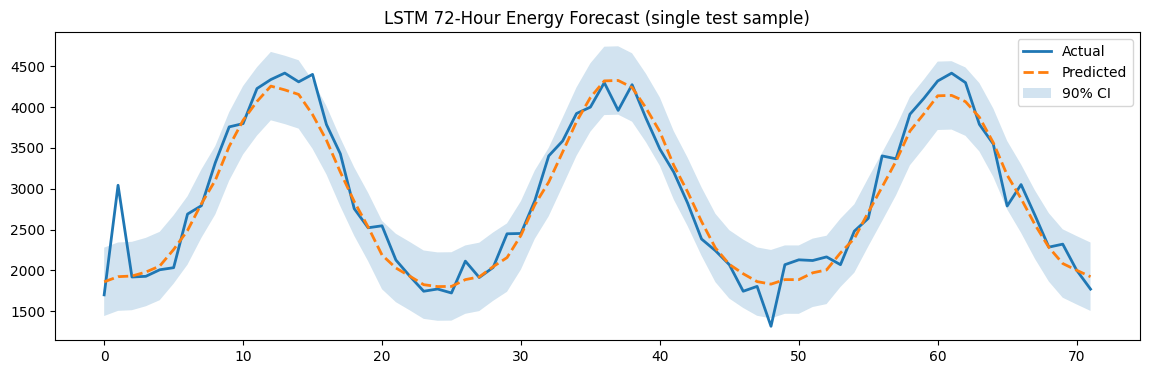

In [11]:
# ─── Evaluate + compute residual std for confidence bands ─────────────────────
# We need a demand-only scaler to inverse transform col-0 predictions
demand_scaler = MinMaxScaler()
demand_scaler.fit(df[['gross_demand_kw']].values)
joblib.dump(demand_scaler, f'{MODELS_DIR}/demand_scaler.pkl')

pred_scaled = lstm_model.predict(X_te)            # (N, 72) — scaled
# inverse: reshape to (-1,1), inverse, reshape back
pred_kw = demand_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(pred_scaled.shape)
true_kw = demand_scaler.inverse_transform(y_te.reshape(-1, 1)).reshape(y_te.shape)

residuals = true_kw - pred_kw
residual_std = float(np.std(residuals))
print(f'Residual std: {residual_std:.1f} kW')

# Save residual_std so edge function can build CI
with open(f'{MODELS_DIR}/lstm_metadata.json', 'w') as f:
    json.dump({'residual_std_kw': residual_std, 'window': WINDOW, 'horizon': HORIZON, 'n_features': N_FEAT}, f)

mae = mean_absolute_error(true_kw.flatten(), pred_kw.flatten())
rmse = np.sqrt(mean_squared_error(true_kw.flatten(), pred_kw.flatten()))
print(f'MAE: {mae:.1f} kW   RMSE: {rmse:.1f} kW')

# Quick plot
fig, ax = plt.subplots(figsize=(14, 4))
sample_true = true_kw[0]
sample_pred = pred_kw[0]
ax.plot(sample_true, label='Actual', lw=2)
ax.plot(sample_pred, label='Predicted', lw=2, ls='--')
ax.fill_between(range(HORIZON),
                sample_pred - 1.65 * residual_std,
                sample_pred + 1.65 * residual_std,
                alpha=0.2, label='90% CI')
ax.set_title('LSTM 72-Hour Energy Forecast (single test sample)')
ax.legend(); plt.show()

---
## 3. Model 2 — Carbon Forecasting (Ridge Regression)
**Input:** month number, year, temperature mean, previous month carbon  
**Output:** `forecast_tco2e` for next 12 months  
**Saves:** `carbon_forecaster.pkl`

Carbon MAE: 113.15 tCO₂e
✅ Carbon forecaster saved


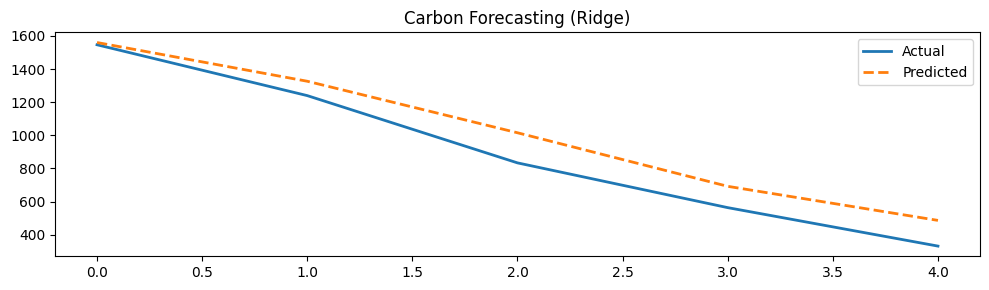

In [12]:
# Monthly temperature mean
monthly_temp = df['temperature'].resample('ME').mean().reset_index()
monthly_temp.columns = ['month_end', 'avg_temp']
monthly_all = monthly.merge(monthly_temp, on='month_end')

# Lag features
monthly_all['prev_carbon']  = monthly_all['actual_tco2e'].shift(1)
monthly_all['prev2_carbon'] = monthly_all['actual_tco2e'].shift(2)
monthly_all['month_sin']    = np.sin(2 * np.pi * monthly_all['month'] / 12)
monthly_all['month_cos']    = np.cos(2 * np.pi * monthly_all['month'] / 12)
monthly_all = monthly_all.dropna()

C_FEATURES = ['month_sin', 'month_cos', 'avg_temp', 'prev_carbon', 'prev2_carbon', 'year']
Xc = monthly_all[C_FEATURES].values
yc = monthly_all['actual_tco2e'].values

split_c = int(0.8 * len(Xc))
Xc_tr, Xc_te = Xc[:split_c], Xc[split_c:]
yc_tr, yc_te = yc[:split_c], yc[split_c:]

carbon_scaler = StandardScaler()
Xc_tr_s = carbon_scaler.fit_transform(Xc_tr)
Xc_te_s = carbon_scaler.transform(Xc_te)

carbon_model = Ridge(alpha=1.0)
carbon_model.fit(Xc_tr_s, yc_tr)

yc_pred = carbon_model.predict(Xc_te_s)
print(f'Carbon MAE: {mean_absolute_error(yc_te, yc_pred):.2f} tCO₂e')

# Save pipeline
carbon_pipeline = Pipeline([('scaler', carbon_scaler), ('model', carbon_model)])
joblib.dump(carbon_pipeline, f'{MODELS_DIR}/carbon_forecaster.pkl')
print('✅ Carbon forecaster saved')

plt.figure(figsize=(10, 3))
plt.plot(yc_te, label='Actual', lw=2)
plt.plot(yc_pred, label='Predicted', lw=2, ls='--')
plt.title('Carbon Forecasting (Ridge)')
plt.legend(); plt.tight_layout(); plt.show()

---
## 4. Model 3 — Building Efficiency Clustering (K-Means)
**Input:** `[eui, hvac_score, carbon_score, lighting_score, occupancy_rate, building_age]`  
**Output:** cluster label (0=Efficient, 1=Average, 2=Poor) + updated scores  
**Saves:** `building_clusterer.pkl`

In [14]:
buildings_df['building_age'] = 2025 - buildings_df['year_built']

CLUSTER_FEATURES = ['eui', 'hvac_score', 'carbon_score', 'lighting_score', 'occupancy_rate', 'building_age']
Xb = buildings_df[CLUSTER_FEATURES].values

cluster_scaler = StandardScaler()
Xb_s = cluster_scaler.fit_transform(Xb)

# Find optimal k via silhouette
sil_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_scores.append(silhouette_score(Xb_s, km.fit_predict(Xb_s)))
best_k = range(2, 7)[np.argmax(sil_scores)]
print(f'Best k = {best_k}, silhouette = {max(sil_scores):.3f}')

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
buildings_df['efficiency_cluster'] = kmeans.fit_predict(Xb_s)

# Label clusters by mean EUI (lower EUI = better) — dynamically sized label list
ALL_LABELS = ['Excellent', 'Efficient', 'Average', 'Below Average', 'Poor', 'Critical']
cluster_eui = buildings_df.groupby('efficiency_cluster')['eui'].mean().sort_values()
label_map = {c: ALL_LABELS[i] for i, c in enumerate(cluster_eui.index)}
buildings_df['efficiency_label'] = buildings_df['efficiency_cluster'].map(label_map)

print(buildings_df[['name', 'type', 'eui', 'efficiency_cluster', 'efficiency_label']].to_string())

building_cluster_pipeline = Pipeline([('scaler', cluster_scaler), ('kmeans', kmeans)])
joblib.dump(building_cluster_pipeline, f'{MODELS_DIR}/building_clusterer.pkl')
print('✅ Building clusterer saved')


Best k = 6, silhouette = 0.243
       name      type     eui  efficiency_cluster efficiency_label
0   Block-A    Sports   337.7                   0             Poor
1   Block-B       Lab   128.6                   3    Below Average
2   Block-C     Admin   719.8                   1        Efficient
3   Block-D     Admin   732.3                   3    Below Average
4   Block-E    Sports   247.0                   5        Excellent
5   Block-F       Lab   508.5                   0             Poor
6   Block-G  Academic   704.8                   0             Poor
7   Block-H       Lab   432.5                   3    Below Average
8   Block-I    Hostel   250.0                   1        Efficient
9   Block-J    Hostel   490.9                   0             Poor
10  Block-K  Academic    98.0                   5        Excellent
11  Block-L    Sports   220.3                   1        Efficient
12  Block-M  Academic  1518.9                   4         Critical
13  Block-N    Sports   351.3  

---
## 5. Model 4 — Anomaly Detection (Isolation Forest)
**Input:** `[demand_kw, hour, dow, temp, solar_irr, demand_rolling_mean, demand_rolling_std]`  
**Output:** anomaly flag (-1=anomaly), anomaly score  
**Saves:** `anomaly_detector.pkl`

Ground-truth anomalies: 189 | Detected: 211
Precision: 27.96%  Recall: 31.22%
✅ Anomaly detector saved


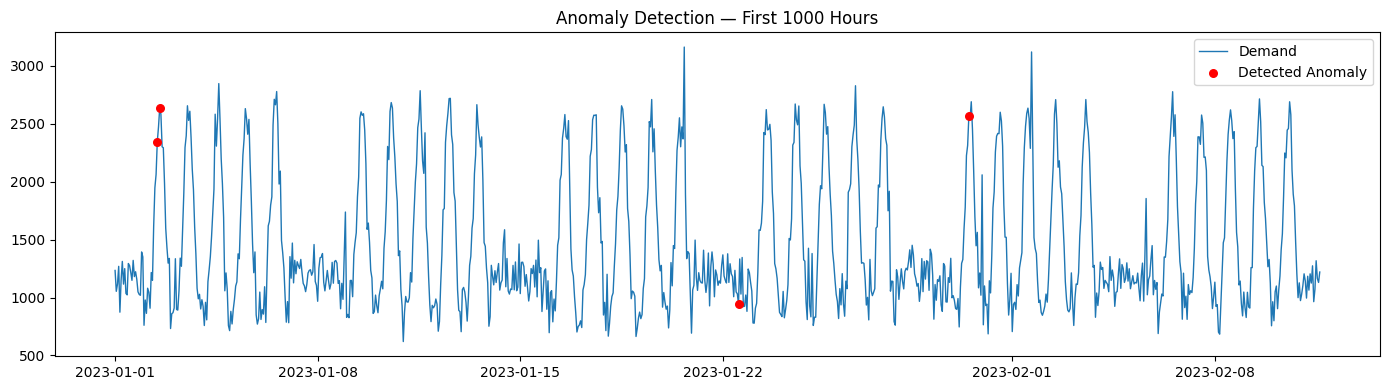

In [15]:
anom_df = df.copy()
anom_df['demand_roll_mean_24'] = anom_df['gross_demand_kw'].rolling(24).mean().fillna(method='bfill')
anom_df['demand_roll_std_24']  = anom_df['gross_demand_kw'].rolling(24).std().fillna(method='bfill')
anom_df['demand_vs_mean']      = anom_df['gross_demand_kw'] - anom_df['demand_roll_mean_24']

ANOM_FEATURES = [
    'gross_demand_kw', 'hour', 'dow', 'temperature',
    'solar_irr', 'demand_roll_mean_24', 'demand_roll_std_24', 'demand_vs_mean'
]
Xa = anom_df[ANOM_FEATURES].values

anom_scaler = StandardScaler()
Xa_s = anom_scaler.fit_transform(Xa)

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.012,   # matches our synthetic anomaly rate
    max_features=0.8,
    random_state=42
)
iso_forest.fit(Xa_s)

preds   = iso_forest.predict(Xa_s)
scores  = iso_forest.score_samples(Xa_s)
detected = (preds == -1).sum()
actual_anomalies = anom_df['is_anomaly'].sum()
print(f'Ground-truth anomalies: {actual_anomalies} | Detected: {detected}')

# Precision on known anomalies
true_pos = ((preds == -1) & (anom_df['is_anomaly'] == 1)).sum()
precision = true_pos / detected if detected > 0 else 0
recall    = true_pos / actual_anomalies if actual_anomalies > 0 else 0
print(f'Precision: {precision:.2%}  Recall: {recall:.2%}')

# Save anomaly pipeline
anomaly_pipeline = Pipeline([('scaler', anom_scaler), ('isoforest', iso_forest)])
joblib.dump(anomaly_pipeline, f'{MODELS_DIR}/anomaly_detector.pkl')

# Save feature list for inference
with open(f'{MODELS_DIR}/anomaly_features.json', 'w') as f:
    json.dump({'features': ANOM_FEATURES}, f)
print('✅ Anomaly detector saved')

# Plot
plot_df = anom_df.iloc[:1000].copy()
plot_preds = preds[:1000]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_df.index, plot_df['gross_demand_kw'], lw=1, label='Demand')
anomaly_idx = plot_df.index[plot_preds == -1]
ax.scatter(anomaly_idx, plot_df.loc[anomaly_idx, 'gross_demand_kw'],
           color='red', s=30, zorder=5, label='Detected Anomaly')
ax.set_title('Anomaly Detection — First 1000 Hours')
ax.legend(); plt.tight_layout(); plt.show()

---
## 6. Model 5 — Retrofit ROI Scorer (Gradient Boosting)
**Input:** building features + retrofit type  
**Output:** `payback_years`, `annual_saving_inr`, `carbon_reduction_tons`  
**Saves:** `retrofit_scorer.pkl`

In [16]:
RETROFIT_TYPES = ['LED Lighting', 'HVAC Upgrade', 'Solar Expansion', 'BMS Installation',
                  'Insulation', 'VFD on Motors', 'Chiller Replacement', 'Smart Metering']
# Base impact parameters per retrofit type
RETROFIT_PARAMS = {
    'LED Lighting':        {'cost_lakhs': (2, 8),    'energy_saving_pct': (15, 30), 'carbon_factor': 0.6},
    'HVAC Upgrade':        {'cost_lakhs': (15, 60),  'energy_saving_pct': (20, 40), 'carbon_factor': 0.85},
    'Solar Expansion':     {'cost_lakhs': (20, 120), 'energy_saving_pct': (10, 25), 'carbon_factor': 1.2},
    'BMS Installation':    {'cost_lakhs': (8, 25),   'energy_saving_pct': (8, 18),  'carbon_factor': 0.5},
    'Insulation':          {'cost_lakhs': (5, 20),   'energy_saving_pct': (5, 15),  'carbon_factor': 0.4},
    'VFD on Motors':       {'cost_lakhs': (3, 12),   'energy_saving_pct': (10, 22), 'carbon_factor': 0.55},
    'Chiller Replacement': {'cost_lakhs': (30, 90),  'energy_saving_pct': (25, 45), 'carbon_factor': 0.9},
    'Smart Metering':      {'cost_lakhs': (1, 5),    'energy_saving_pct': (3, 8),   'carbon_factor': 0.2},
}

TARIFF_PER_KWH = 8.5   # ₹/kWh average Indian campus tariff

# Generate synthetic retrofit records
np.random.seed(13)
n_records = 2000
retrofit_records = []

for _ in range(n_records):
    btype = np.random.choice(BUILDING_TYPES)
    rtype = np.random.choice(RETROFIT_TYPES)
    area  = np.random.randint(1500, 12000)
    eui   = np.random.uniform(50, 400)
    hvac_age = np.random.randint(1, 30)
    current_demand_kw = eui * area / 8760

    p = RETROFIT_PARAMS[rtype]
    cost_lakhs = np.random.uniform(*p['cost_lakhs'])
    # Higher-EUI buildings benefit more
    eui_boost  = np.clip(eui / 200, 0.5, 1.5)
    saving_pct = np.random.uniform(*p['energy_saving_pct']) * eui_boost
    annual_kwh_saved = current_demand_kw * 8760 * (saving_pct / 100)
    annual_saving_inr = annual_kwh_saved * TARIFF_PER_KWH
    carbon_reduction  = annual_kwh_saved * 0.71 / 1000   # tCO2
    payback_years     = (cost_lakhs * 1e5) / annual_saving_inr

    retrofit_records.append({
        'building_type': btype, 'retrofit_type': rtype,
        'area_sqm': area, 'eui': eui, 'hvac_age_yrs': hvac_age,
        'cost_lakhs': cost_lakhs,
        'annual_saving_inr': annual_saving_inr,
        'carbon_reduction_tons': carbon_reduction,
        'payback_years': payback_years,
    })

retrofit_df = pd.DataFrame(retrofit_records)
retrofit_df = retrofit_df[retrofit_df['payback_years'] < 25]   # filter unrealistic

# Encode categoricals
retrofit_df = pd.get_dummies(retrofit_df, columns=['building_type', 'retrofit_type'])
R_FEATURES  = [c for c in retrofit_df.columns if c not in ['annual_saving_inr', 'carbon_reduction_tons', 'payback_years', 'cost_lakhs']]

Xr = retrofit_df[R_FEATURES].values
yr_payback = retrofit_df['payback_years'].values
yr_saving  = retrofit_df['annual_saving_inr'].values
yr_carbon  = retrofit_df['carbon_reduction_tons'].values

split_r = int(0.8 * len(Xr))

# Train three GBR models
models_retrofit = {}
for target_name, y_target in [('payback_years', yr_payback), ('annual_saving_inr', yr_saving), ('carbon_reduction_tons', yr_carbon)]:
    gbr = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
    gbr.fit(Xr[:split_r], y_target[:split_r])
    pred_t = gbr.predict(Xr[split_r:])
    mae_t  = mean_absolute_error(y_target[split_r:], pred_t)
    print(f'{target_name}: MAE = {mae_t:.3f}')
    models_retrofit[target_name] = gbr

retrofit_payload = {
    'models': models_retrofit,
    'feature_columns': R_FEATURES,
    'building_types': BUILDING_TYPES,
    'retrofit_types': RETROFIT_TYPES,
}
joblib.dump(retrofit_payload, f'{MODELS_DIR}/retrofit_scorer.pkl')
print('✅ Retrofit scorer saved')

payback_years: MAE = 0.750
annual_saving_inr: MAE = 632109.788
carbon_reduction_tons: MAE = 52.751
✅ Retrofit scorer saved


---
## 7. Model 6 — AI Recommendation Engine (Rule-Based + GBR Scoring)
**Input:** campus energy profile snapshot  
**Output:** ranked list of `ai_recommendations` with `roi_pct`, `ease_score`, `confidence_pct`, `priority`  
**Saves:** `recommendation_engine.pkl`

In [17]:
np.random.seed(22)
n_recs = 1500

rec_records = []
CATEGORIES = ['HVAC', 'Lighting', 'Solar', 'Behaviour', 'Procurement', 'Monitoring', 'Insulation']
IMPACT_MAP  = {'HVAC': 0.4, 'Solar': 0.35, 'Lighting': 0.2, 'Insulation': 0.15,
               'Procurement': 0.1, 'Behaviour': 0.08, 'Monitoring': 0.06}

for _ in range(n_recs):
    cat          = np.random.choice(CATEGORIES)
    base_impact  = IMPACT_MAP[cat]
    eui          = np.random.uniform(50, 400)
    campus_rf    = np.random.uniform(0.1, 0.6)   # renewable fraction
    anomaly_rate = np.random.uniform(0, 0.05)

    # ROI depends on category + campus state
    roi_base   = base_impact * (1 + (eui - 150) / 300) * 100
    roi_pct    = np.clip(roi_base + np.random.normal(0, 5), 2, 80)
    ease_score = np.random.randint(1, 10)   # 1=hard, 10=easy
    confidence = np.clip(70 + np.random.normal(0, 10), 50, 98)
    priority   = 1 if roi_pct > 40 else (2 if roi_pct > 20 else 3)

    rec_records.append({
        'category': cat, 'eui': eui, 'renewable_fraction': campus_rf,
        'anomaly_rate': anomaly_rate, 'roi_pct': roi_pct,
        'ease_score': ease_score, 'confidence_pct': confidence, 'priority': priority
    })

rec_df = pd.DataFrame(rec_records)
rec_df = pd.get_dummies(rec_df, columns=['category'])
REC_FEATURES = [c for c in rec_df.columns if c not in ['roi_pct', 'ease_score', 'confidence_pct', 'priority']]

Xrec = rec_df[REC_FEATURES].values
split_rec = int(0.8 * len(Xrec))

rec_models = {}
for tname, ytarget in [('roi_pct', rec_df['roi_pct'].values),
                        ('ease_score', rec_df['ease_score'].values),
                        ('confidence_pct', rec_df['confidence_pct'].values)]:
    m = GradientBoostingRegressor(n_estimators=150, max_depth=3, learning_rate=0.08, random_state=42)
    m.fit(Xrec[:split_rec], ytarget[:split_rec])
    p = m.predict(Xrec[split_rec:])
    print(f'{tname} MAE: {mean_absolute_error(ytarget[split_rec:], p):.3f}')
    rec_models[tname] = m

rec_payload = {'models': rec_models, 'feature_columns': REC_FEATURES, 'categories': CATEGORIES}
joblib.dump(rec_payload, f'{MODELS_DIR}/recommendation_engine.pkl')
print('✅ Recommendation engine saved')

roi_pct MAE: 3.863
ease_score MAE: 2.360
confidence_pct MAE: 8.174
✅ Recommendation engine saved


---
## 8. Model 7 — Load Profile Classifier (Random Forest)
**Input:** hourly demand + calendar features  
**Output:** day_type label (`weekday` / `weekend` / `holiday`) + per-hour load profile  
**Saves:** `load_classifier.pkl`

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

load_df = df.copy()

# Day-type labels
# Public holidays (approx Indian academic calendar)
holiday_months_days = [(1,26),(8,15),(10,2),(1,1),(4,14)]
def is_holiday(ts):
    return any(ts.month == m and ts.day == d for m, d in holiday_months_days)

load_df['is_holiday'] = [is_holiday(ts) for ts in load_df.index]
load_df['day_type_label'] = 'weekday'
load_df.loc[load_df.index.dayofweek >= 5, 'day_type_label'] = 'weekend'
load_df.loc[load_df['is_holiday'], 'day_type_label'] = 'holiday'

LC_FEATURES = ['gross_demand_kw', 'hour', 'dow', 'month', 'temperature',
               'occupancy', 'solar_irr', 'hour_sin', 'hour_cos']

Xl = load_df[LC_FEATURES].values
yl = load_df['day_type_label'].values

split_l = int(0.8 * len(Xl))
Xl_tr, Xl_te = Xl[:split_l], Xl[split_l:]
yl_tr, yl_te = yl[:split_l], yl[split_l:]

lc_scaler = StandardScaler()
Xl_tr_s = lc_scaler.fit_transform(Xl_tr)
Xl_te_s = lc_scaler.transform(Xl_te)

rf_classifier = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_classifier.fit(Xl_tr_s, yl_tr)

yl_pred = rf_classifier.predict(Xl_te_s)
print(classification_report(yl_te, yl_pred))

load_pipeline = Pipeline([('scaler', lc_scaler), ('clf', rf_classifier)])
joblib.dump(load_pipeline, f'{MODELS_DIR}/load_classifier.pkl')

with open(f'{MODELS_DIR}/load_features.json', 'w') as f:
    json.dump({'features': LC_FEATURES}, f)
print('✅ Load classifier saved')

              precision    recall  f1-score   support

     holiday       0.00      0.00      0.00        48
     weekday       0.98      1.00      0.99      2448
     weekend       1.00      1.00      1.00      1008

    accuracy                           0.99      3504
   macro avg       0.66      0.67      0.66      3504
weighted avg       0.97      0.99      0.98      3504

✅ Load classifier saved


---
## 9. Summary — All Saved Files

In [19]:
import os
files = os.listdir(MODELS_DIR)
total_mb = sum(os.path.getsize(f'{MODELS_DIR}/{f}') for f in files) / 1e6
print(f'\n📦 Saved {len(files)} model files  ({total_mb:.1f} MB total)\n')
for f in sorted(files):
    size_kb = os.path.getsize(f'{MODELS_DIR}/{f}') / 1024
    print(f'  {f:<40}  {size_kb:>8.1f} KB')


📦 Saved 12 model files  (15.1 MB total)

  anomaly_detector.pkl                        4796.9 KB
  anomaly_features.json                          0.1 KB
  building_clusterer.pkl                         1.7 KB
  carbon_forecaster.pkl                          1.2 KB
  demand_scaler.pkl                              0.7 KB
  load_classifier.pkl                         6429.9 KB
  load_features.json                             0.1 KB
  lstm_forecaster.keras                       1560.5 KB
  lstm_metadata.json                             0.1 KB
  lstm_scaler.pkl                                1.0 KB
  recommendation_engine.pkl                    594.1 KB
  retrofit_scorer.pkl                         1405.9 KB


In [20]:
# ─── Zip everything for a single download ─────────────────────────────────────
import shutil
shutil.make_archive('/kaggle/working/ecovista_models', 'zip', MODELS_DIR)
print('✅ Download: /kaggle/working/ecovista_models.zip')

✅ Download: /kaggle/working/ecovista_models.zip


---
## 10. Deployment Guide — Supabase Storage + Edge Functions

Since Vercel is **serverless and stateless** (no persistent disk), you cannot load `.pkl` files directly from the filesystem in production. The correct architecture is:

```
Kaggle → train → ecovista_models.zip
    ↓
Supabase Storage Bucket ("ml-models")
    ↓
Supabase Edge Function (Deno, Python via WASM or external inference)
    ↓ (REST call)
Vite/React frontend
```

### Step-by-Step Upload to Supabase Storage

**Step 1 — Create bucket**
```sql
-- In Supabase SQL Editor:
INSERT INTO storage.buckets (id, name, public)
VALUES ('ml-models', 'ml-models', false);
```

**Step 2 — Upload files (Python script, run locally)**
```python
import os
from supabase import create_client

url = 'https://technex.jiobase.com'
key = '<your-service-role-key>'   # NOT the publishable key — use service role
supabase = create_client(url, key)

MODEL_FILES = [
    'lstm_forecaster.keras',
    'lstm_scaler.pkl',
    'demand_scaler.pkl',
    'lstm_metadata.json',
    'carbon_forecaster.pkl',
    'building_clusterer.pkl',
    'anomaly_detector.pkl',
    'anomaly_features.json',
    'retrofit_scorer.pkl',
    'recommendation_engine.pkl',
    'load_classifier.pkl',
    'load_features.json',
]

for fname in MODEL_FILES:
    with open(f'models/{fname}', 'rb') as f:
        data = f.read()
    res = supabase.storage.from_('ml-models').upload(fname, data, {'upsert': 'true'})
    print(f'Uploaded {fname}: {res}')
```

**Step 3 — Edge Function for anomaly detection (example)**

Because Deno (Supabase Edge Functions runtime) cannot run Python natively, you have two options:

**Option A (Recommended) — Python Flask microservice on Railway/Render (free tier)**
Deploy a tiny Python API alongside Supabase. The Edge Function or frontend calls it via HTTP.

**Option B — ONNX Export + Deno ONNX runtime**
Export scikit-learn models to ONNX format so they run in the JS/Deno runtime:
```python
# Run this after training:
!pip install skl2onnx onnxruntime
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnx

# Example: anomaly detector
initial_type = [('float_input', FloatTensorType([None, 8]))]
onnx_model = convert_sklearn(iso_forest, initial_types=initial_type)
with open(f'{MODELS_DIR}/anomaly_detector.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())
```
Then load in Deno Edge Function:
```typescript
// supabase/functions/detect-anomaly/index.ts
import * as ort from 'https://cdn.jsdelivr.net/npm/onnxruntime-web/dist/ort.min.js';

const { data } = await supabase.storage.from('ml-models').download('anomaly_detector.onnx');
const arrayBuffer = await data.arrayBuffer();
const session = await ort.InferenceSession.create(new Uint8Array(arrayBuffer));
// Run inference...
```

### Tell me which option you prefer and I will write the full integration code.